# Data Quality Investigation: Private Water Supplies in Leeds

This notebook applies steps 1–4 of Roy Ruddle’s six-step data quality workflow to the Private Water Supplies dataset from Data Mill North.

Dataset URL: https://datamillnorth.org/dataset/private-water-supplies-e515n

Topic: Business and Economy

Note from metadata:
"
A dataset of private water supplies on commercial premises, with OS grid reference.

A private water supply (PWS) is a supply of water which is not provided by a water supplier (e.g. Yorkshire Water). The source of the supply may come from a:

* Well
* Borehole
* Spring
* River or stream
* Lake or pond
Private distribution system (mains water privately distributed by a second party)
The supply may serve one property or several properties.
"

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import datetime

from vizdataquality import calculate as vdqc, datasets as vdqd, plot as vdqp, report as vdqr

## Loading the dataset

In [3]:
DATASET_NAME = "private_water"
ID_COL = None   # or "Library" in dataset 1
WIDE_TIME_SERIES = False  # True for libraries dataset

dataset_filename = "../data/private_water.csv"
df1 = pd.read_csv(dataset_filename)
num_rows = df1.shape[0]
num_col = df1.shape[1]
print("rows:", num_rows, "|| columns:", num_col)
print(df1.columns)
df_output1 = vdqc.calc(df1) # creating a dataframe of data quality metrics for each column
print(df_output1)

rows: 16 || columns: 5
Index(['Name of Supply', 'Postcode', 'OS Grid Ref',
       'Type of Water Use e.g. Domestic', 'Source'],
      dtype='object')
                                Data type        Example value  \
_column                                                          
Name of Supply                     object  John Penny and Sons   
Postcode                           object             LS14 3HG   
OS Grid Ref                        object      SE214310 391920   
Type of Water Use e.g. Domestic    object     Commercial/Large   
Source                             object             Borehole   

                                 Number of values  Number of zero values  \
_column                                                                    
Name of Supply                                 16                      0   
Postcode                                       16                      0   
OS Grid Ref                                    16                      0   
Type of

## Initialising the report

In [5]:
overwrite = True
report_folder = "../reports"

if True:
    report_filename = "private_water_report.html"
    table_kw = {}
else:
    report_filename = "private_water_report.tex"
    mpl.rcParams["savefig.dpi"] = 300
    table_kw = {"position": "h!"}

report = vdqr.Report()

report.add_title("Data quality issues and profiling of a private water supplies dataset")

text = (
    "This report has been produced by applying the vizdataquality package to investigate "
    "data quality of a dataset about private water supplies in Leeds. "
    "The data is from Data Mill North and is used here to evaluate Steps 1–4 of "
    "Roy Ruddle’s structured profiling workflow."
)
report.add_heading("Introduction", text=text)

text = "The first four workflow steps investigate data quality and clean the dataset in a structured manner."
report.paragraph(text)

3

## Workflow Step 1: Look at your data

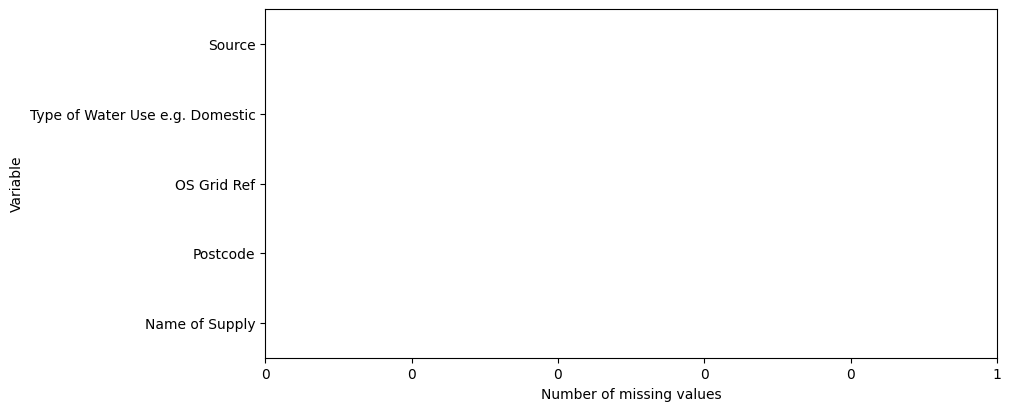

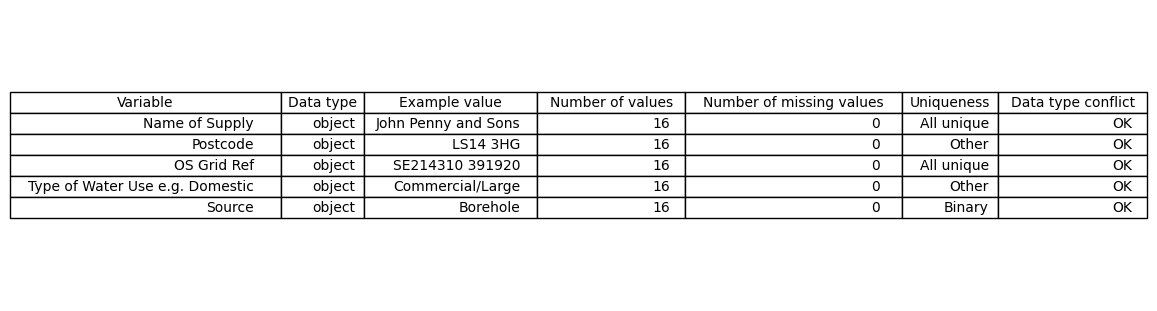

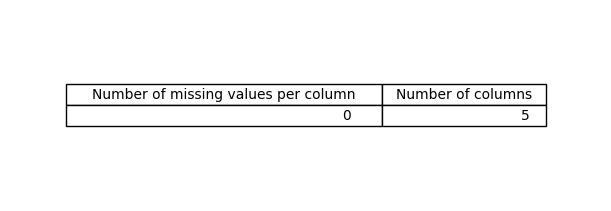

,Number of missing values per column,Number of columns
0,0,5


In [7]:
# Plot missingness (all should be zero)
cols = ["Number of missing values"]
missing_sorted = df_output1[cols].sort_values("Number of missing values", ascending=False)

fig_kw = {"size_inches": (10, 4), "constrained_layout": True}
vdqp.plotgrid("scalars", missing_sorted, num_cols=1, vert=False, fig_kw=fig_kw)

# Summary table
summary_cols = [
    "Data type",
    "Example value",
    "Number of values",
    "Number of missing values",
    "Uniqueness",
    "Data type conflict"
]
summary = df_output1[summary_cols].copy()

vdqp.table(
    summary,
    include_index=True,
    fig_kw={"size_inches": (12, 3), "constrained_layout": True},
    loc="center"
)

# Missingness distribution table
missing_distribution = (
    df_output1["Number of missing values"]
    .value_counts()
    .sort_index()
    .rename_axis("Number of missing values per column")
    .reset_index(name="Number of columns")
)

vdqp.table(
    missing_distribution,
    include_index=False,
    fig_kw={"size_inches": (6, 2), "constrained_layout": True},
    loc="center"
)

missing_distribution

## Observations (Step 1)

- Dataset shape: 16 rows × 5 columns.
- All variables are text-based (`object`).
- No missing values are present in any column.
- No data type conflicts were detected.
- “Name of Supply” and “OS Grid Ref” are unique across all rows.
- “Source” behaves as a binary variable, while “Postcode” and “Type of Water Use” behave as categorical variables.
- The dataset is a narrow, record-based table rather than a wide time-series dataset.

## Design Implications (Step 1)

- Structural missingness detection is not required for narrow registry-style datasets.
- No structural cleaning is necessary before proceeding to Step 2.
- Because all variables are text-based, later validation must focus on format and category consistency rather than numeric plausibility.
- The workflow must support both wide time-series and narrow registry-style datasets without assuming structural cleaning is always required.

In [8]:
report.step1(
    "The dataset is a narrow, record-based table (16 rows × 5 columns), "
    "with one row per private water supply. All variables are text-based "
    "and fully populated (0 missing values). No data type conflicts were detected. "
    "Unlike wide time-series datasets, no structural empty columns were present, "
    "so no cleaning was required prior to subsequent workflow steps."
)

4

## Workflow Step 2: Watch out for special values

In [9]:
# Identify object columns
object_cols = df1.select_dtypes(include="object").columns

# Check blank strings / whitespace-only
for col in object_cols:
    stripped = df1[col].astype(str).str.strip()
    if (stripped == "").any():
        print("Blank string detected in:", col)

# Check common text sentinels (case-insensitive)
common_text_sentinels = {"n/a", "unknown", "-", "null", "none"}

for col in object_cols:
    lower_values = df1[col].astype(str).str.strip().str.lower()
    if lower_values.isin(common_text_sentinels).any():
        print("Potential text sentinel in:", col)

# Inspect unique values per column
for col in object_cols:
    print(f"\nUnique values in {col}:")
    print(df1[col].astype(str).str.strip().unique())


Unique values in Name of Supply:
['John Penny and Sons' "Goodall's Beech Grove Farm" 'William Strikes Ltd'
 'Scarcroft golf Club' 'Moor Valley Leisure Ltd'
 'Chevin Country Park Hotel & Spa' 'Greenside Farm' 'Stubhouse Farm'
 'Chevin Forest Park The White House' 'Hopewell Equestrian Centre'
 'Olicana Properties' 'Burden Head Farm' 'Green Gaits Farm'
 'Creskeld Hall / Creskeld House' 'Linton Springs Farm'
 'Goodhalls Beech Grove Farm']

Unique values in Postcode:
['LS19 6NU' 'LS14 3HG' 'LS25 2AQ' 'LS14 3BQ' 'LS20 8PG' 'LS21 3NU'
 'LS19 7DW' 'LS17 9LF' 'LS21  3JL' 'LS20 9NW' 'LS21 1PH' 'LS16 8AY'
 'LS18 5HY' 'LS21 1NT' 'LS22 4AQ']

Unique values in OS Grid Ref:
['SE214310 391920' 'SE354010 695910' 'SE416110 319480' 'SE362390 418790'
 'SE154750 416100' 'SE211680 438730' 'SE203460 401850' 'SE307750 445830'
 'SE201190 445560' 'SE207440 429750' 'SE273600 449620' 'SE289930 435180'
 'SE232220 425650' 'SE 259600 443080' 'SE 374020480690' 'SE354010695910']

Unique values in Type of Water Use e.

## Observations (Step 2)

- No numeric columns are present, so numeric sentinel checks are not applicable.
- No blank strings or whitespace-only entries were detected.
- No common textual sentinel encodings (e.g. “n/a”, “unknown”, “null”) were found.
- Missing values appear consistently absent and no recoding was required.

## Design Implications (Step 2)

- Sentinel detection must be type-aware (numeric vs textual).
- Workflow Step 2 cannot assume numeric variables are present.
- Missingness detection should include blank strings, not only NaN values.
- Registry-style datasets require category and formatting validation rather than numeric sentinel detection.

In [10]:
report.step2(
    "All variables are text-based, so numeric sentinel checks were not applicable. "
    "Text columns were scanned for blank strings, whitespace-only entries, and common textual sentinel encodings (e.g., 'n/a', 'unknown', 'null'), using case-insensitive comparison. "
    "No such encodings were detected. "
    "Missing values appear consistently absent and no recoding was required."
)

5

## Workflow Step 3: Is any data missing?

In [11]:
missing_counts = df1.isna().sum()
print(missing_counts)

Name of Supply                     0
Postcode                           0
OS Grid Ref                        0
Type of Water Use e.g. Domestic    0
Source                             0
dtype: int64


## Observations (Step 3)

- After Step 2 validation, no variables contain missing values.
- No structural missingness (Step 1) or encoded missingness (Step 2) was identified.
- The dataset is fully populated across all records and attributes.

## Design Implications (Step 3)

- The workflow must confirm absence of missingness explicitly, even when prior steps detect no issues.
- Complete population does not imply correctness; further validation (Step 4) is still required.
- The pipeline should treat “no missing data” as a verifiable outcome rather than an assumption.

In [12]:
report.step3(
    "Following structural checks (Step 1) and encoded missingness checks (Step 2), "
    "no variables contain missing values. The dataset is fully populated across "
    "all attributes. Although no missingness is present, further validation "
    "(Step 4) is still required to assess correctness and consistency."
)

6

## Workflow Step 4: Check each variable

This step focuses on variable-level validation, examining whether each column behaves consistently with expectations, in line with the structured profiling workflow proposed by Ruddle et al. (2024).

In [13]:
print("STEP 4: Variable-Level Validation\n")

# Duplicate records
duplicate_rows = df1.duplicated().sum()
print("Duplicate records:", duplicate_rows)

# Name of Supply uniqueness
unique_names = df1["Name of Supply"].nunique()
print("Unique supply names:", unique_names)

# Postcode format validation
postcode_pattern = r"^[A-Z]{1,2}[0-9][0-9A-Z]?\s?[0-9][A-Z]{2}$"

invalid_postcodes = df1[
    ~df1["Postcode"].astype(str).str.strip().str.match(postcode_pattern)
]

print("Invalid postcodes:", len(invalid_postcodes))
print(invalid_postcodes[["Name of Supply", "Postcode"]])

# OS Grid Reference validation
grid_pattern = r"^[A-Z]{2}\d+\s\d+$"

invalid_grid_refs = df1[
    ~df1["OS Grid Ref"].astype(str).str.strip().str.match(grid_pattern)
]

print("Invalid OS Grid References:", len(invalid_grid_refs))
print(invalid_grid_refs[["Name of Supply", "OS Grid Ref"]])

# Unique categories
print("\nUnique categories:")
print("Type of Water Use:", df1["Type of Water Use e.g. Domestic"].str.strip().unique())
print("Source:", df1["Source"].str.strip().unique())

# Whitespace issues
for col in df1.columns:
    if df1[col].astype(str).str.contains(r"^\s+|\s+$", regex=True).any():
        print("Whitespace issue detected in:", col)

print("\nStep 4 validation complete.")

STEP 4: Variable-Level Validation

Duplicate records: 0
Unique supply names: 16
Invalid postcodes: 1
                       Name of Supply   Postcode
8  Chevin Forest Park The White House  LS21  3JL
Invalid OS Grid References: 3
                    Name of Supply       OS Grid Ref
13  Creskeld Hall / Creskeld House  SE 259600 443080
14             Linton Springs Farm   SE 374020480690
15      Goodhalls Beech Grove Farm    SE354010695910

Unique categories:
Type of Water Use: ['Commercial/Large' 'Commercial']
Source: ['Borehole' 'Spring']
Whitespace issue detected in: Postcode
Whitespace issue detected in: Type of Water Use e.g. Domestic

Step 4 validation complete.


## Observations (Step 4)

- No duplicate records were detected.
- One postcode failed regex validation due to inconsistent spacing.
- Three OS Grid References failed strict format validation.
- Whitespace inconsistencies were detected in “Postcode” and “Type of Water Use”.
- “Type of Water Use” contains two closely related categories (“Commercial” and “Commercial/Large”), suggesting possible semantic inconsistency.
- No missing values are present, but formatting inconsistencies remain.

## Design Implications (Step 4)

- Format validation must distinguish between structural invalidity and normalisation issues such as extra whitespace.
- The pipeline should include automatic normalisation steps, such as trimming and collapsing repeated spaces.
- Text-based datasets require semantic and format validation beyond missing-value checks.
- Category fields may require controlled vocabulary enforcement or standardisation rules.
- Absence of missing values does not imply high data quality.

In [14]:
report.step4(
    "Variable-level validation was conducted to assess whether each attribute "
    "behaves consistently with domain expectations. One postcode failed format "
    "validation due to inconsistent spacing, and three OS Grid References did "
    "not match the expected coordinate pattern. Whitespace inconsistencies were "
    "also detected in text fields, and the 'Type of Water Use' column showed "
    "closely related but non-identical categories ('Commercial' and "
    "'Commercial/Large'). This indicates that, although the dataset contains "
    "no missing values, format and standardisation issues remain. The results "
    "reinforce the need for type-aware validation and normalisation logic in a "
    "generalisable profiling pipeline."
)

7

In [15]:
os.makedirs(report_folder, exist_ok=True)
report_path = os.path.join(report_folder, report_filename)
report.save(report_path)

print("Report saved to:", report_path)

Report saved to: ../reports/private_water_report.html
